In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pickle

# Neural x Behavioral Error Correlation

In [2]:
# Replace the single-region CSV load with the all-regions file
df_behavior = pd.read_csv('/home/aarghavan/aslan/delsac-behavior/behavior_all.csv')
df_neural = pd.read_csv('/home/aarghavan/aslan/delsac-neural-decoding/results/errors_angular.csv')

df_neural_target = df_neural[df_neural['angle_name'] == 'targetAngle'].copy()
df_neural_target['time'] = df_neural_target['time'].round(3)
df_neural_target['original_session'] = (
    df_neural_target['original_session']
    .str.strip("[]'")
    .replace('', np.nan)
    .astype(float)
    .astype('Int64')  # nullable integer, tolerates NaN
)
df_neural_target['error_deg'] = np.degrees(df_neural_target['error'])

# Align dtypes for merge keys
# Clean behavior session_id to numeric
df_behavior['session_id'] = (
    df_behavior['session_id']
    .astype(str)
    .str.strip("[]' ")
    .replace('', np.nan)
    .astype(float)
    .astype('Int64')
)
df_behavior['trial_id'] = pd.to_numeric(df_behavior['trial_id'], errors='coerce').astype('Int64')

# Also ensure neural trial key matches
df_neural_target['original_trial'] = pd.to_numeric(df_neural_target['original_trial'], errors='coerce').astype('Int64')

# Merge neural and behavior data
df_merged = df_neural_target.merge(
    df_behavior[['session_id', 'trial_id', 'err']],
    left_on=['original_session', 'original_trial'],
    right_on=['session_id', 'trial_id'],
    how='left'
)

/tmp/ipykernel_3569624/4195214754.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_neural = pd.read_csv('/home/aarghavan/aslan/delsac-neural-decoding/results/errors_angular.csv')


In [3]:
df_merged

,area,session,original_session,original_trial,angle_name,trial,time_idx,time,error,error_deg,session_id,trial_id,err
0,PFC,0,100725,3,targetAngle,0,0,-2.5,0.778638,44.612647,100725,3,4.307453
1,PFC,0,100725,3,targetAngle,0,1,-2.4,1.621403,92.899557,100725,3,4.307453
2,PFC,0,100725,3,targetAngle,0,2,-2.3,0.204964,11.743561,100725,3,4.307453
3,PFC,0,100725,3,targetAngle,0,3,-2.2,1.900231,108.875227,100725,3,4.307453
4,PFC,0,100725,3,targetAngle,0,4,-2.1,2.362186,135.343281,100725,3,4.307453
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1879440,V4,65,<NA>,1415,targetAngle,82,54,2.9,1.848414,105.906317,<NA>,<NA>,NaN
1879441,V4,65,<NA>,1415,targetAngle,82,55,3.0,2.675518,153.295877,<NA>,<NA>,NaN
1879442,V4,65,<NA>,1415,targetAngle,82,56,3.1,2.721201,155.913357,<NA>,<NA>,NaN
1879443,V4,65,<NA>,1415,targetAngle,82,57,3.2,-3.135589,-179.656043,<NA>,<NA>,NaN


In [4]:
print(len(df_merged[(df_merged['area'] == 'PFC') & (df_merged['original_session'] == 100726) & (df_merged['original_trial'] == 6)]))
# df_merged[(df_merged['area'] == 'PFC') & (df_merged['original_session'] == 100726) & (df_merged['original_trial'] == 6)]

59


In [5]:
def circ_corr(alpha, beta):
    """
    Circular correlation coefficient between two angle arrays (radians).
    """
    sin_a = np.sin(alpha - np.mean(alpha))
    sin_b = np.sin(beta - np.mean(beta))
    num = np.sum(sin_a * sin_b)
    den = np.sqrt(np.sum(sin_a**2) * np.sum(sin_b**2))
    return num / den if den != 0 else np.nan

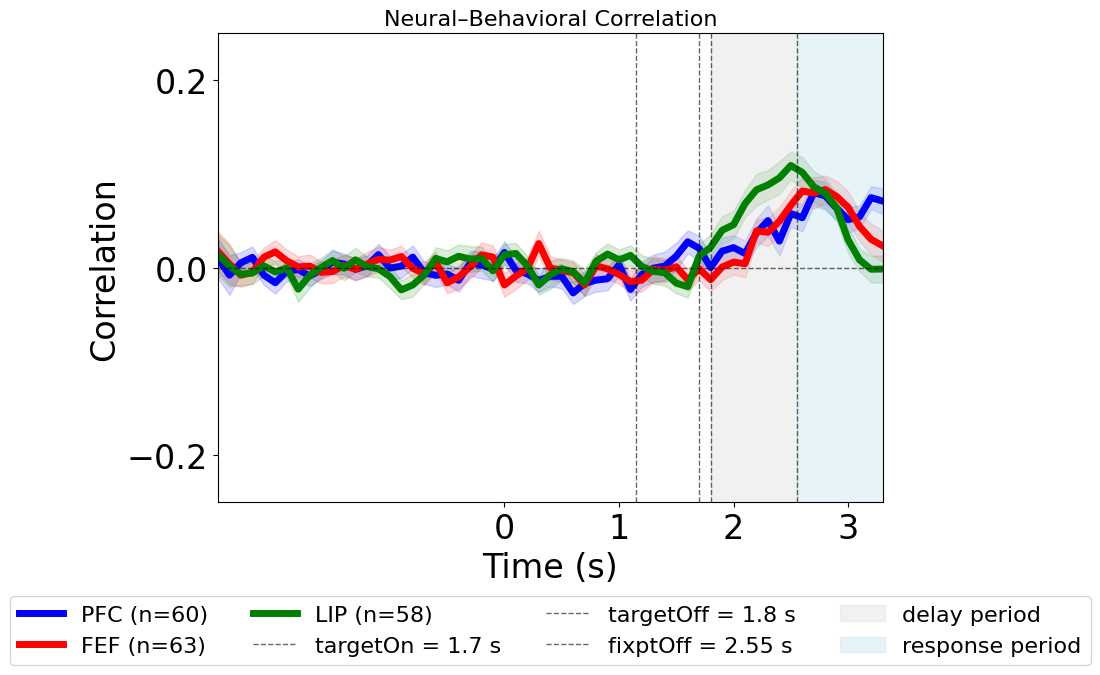

In [6]:
# Compute circular correlation per region, session, and time
regions = ['PFC', 'FEF', 'LIP']
# regions = ['Parietal', 'IT', 'MT', 'V4']
# regions = ['Parietal', 'IT', 'MT', 'V4', 'PFC', 'FEF', 'LIP']
area_colors = {'PFC':'b','FEF':'r','LIP':'g','Parietal':'y','IT':'c','MT':'m','V4':'orange'}

plt.figure(figsize=(10, 7))

for region in regions:
    df_region = df_merged[df_merged['area'] == region]
    times = np.sort(df_region['time'].unique())
    sessions = df_region['session_id'].dropna().unique()

    r_sessions = np.full((len(sessions), len(times)), np.nan)

    for s_idx, session in enumerate(sessions):
        df_s = df_region[df_region['session_id'] == session]

        for t_idx, t in enumerate(times):
            sub = df_s[np.isclose(df_s['time'], t)]

            if len(sub) > 10:
                neural = np.radians(sub['error_deg'].values)
                behav  = np.radians(sub['err'].values)
                r_sessions[s_idx, t_idx] = circ_corr(neural, behav)

    r_mean = np.nanmean(r_sessions, axis=0)
    r_sem  = np.nanstd(r_sessions, axis=0) / np.sqrt(np.sum(~np.isnan(r_sessions), axis=0))

    color = area_colors.get(region, 'black')
    plt.plot(times, r_mean, linewidth=5, label=f'{region} (n={len(sessions)})', color=color)
    plt.fill_between(times, r_mean - r_sem, r_mean + r_sem, alpha=0.15, color=color)

plt.axhline(0, linestyle='--', color='k', alpha=0.6, linewidth=1)

# plt.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.15, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.2, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.35, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.4, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.55, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.6, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.75, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.8, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.95, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(1, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
plt.axvline(1.15, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

plt.axvline(1.7, linestyle='--', color='k', alpha=0.6, label='targetOn = 1.7 s', linewidth=1)
plt.axvline(1.8, linestyle='--', color='k', alpha=0.6, label='targetOff = 1.8 s', linewidth=1)
plt.axvline(2.55, linestyle='--', color='k', alpha=0.6, label='fixptOff = 2.55 s', linewidth=1)
plt.axvspan(1.8, 2.55, color='lightgray', alpha=0.3, label='delay period')
plt.axvspan(2.55, 3.5, color='lightblue', alpha=0.3, label='response period')

plt.xlabel('Time (s)', fontsize=24)
plt.ylabel('Correlation', fontsize=24)
plt.title('Neural–Behavioral Correlation', fontsize=16)
plt.xticks([0, 1, 2, 3], fontsize=24)
plt.yticks([-0.2, 0, 0.2], fontsize=24)
plt.xlim(-2.5, 3.3)
plt.ylim(-0.25, 0.25)
plt.legend(fontsize=16, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, borderaxespad=0)
plt.tight_layout()
plt.show()


PFC (n=60): Delay=0.0277±0.0099, Response=0.0657±0.0098
FEF (n=63): Delay=0.0212±0.0097, Response=0.0605±0.0129
LIP (n=58): Delay=0.0628±0.0118, Response=0.0459±0.0099
Parietal (n=23): Delay=0.0126±0.0145, Response=0.0313±0.0074
IT (n=13): Delay=0.0236±0.0158, Response=0.0091±0.0179
MT (n=22): Delay=-0.0398±0.0190, Response=0.0030±0.0167
V4 (n=27): Delay=-0.0069±0.0109, Response=-0.0575±0.0163


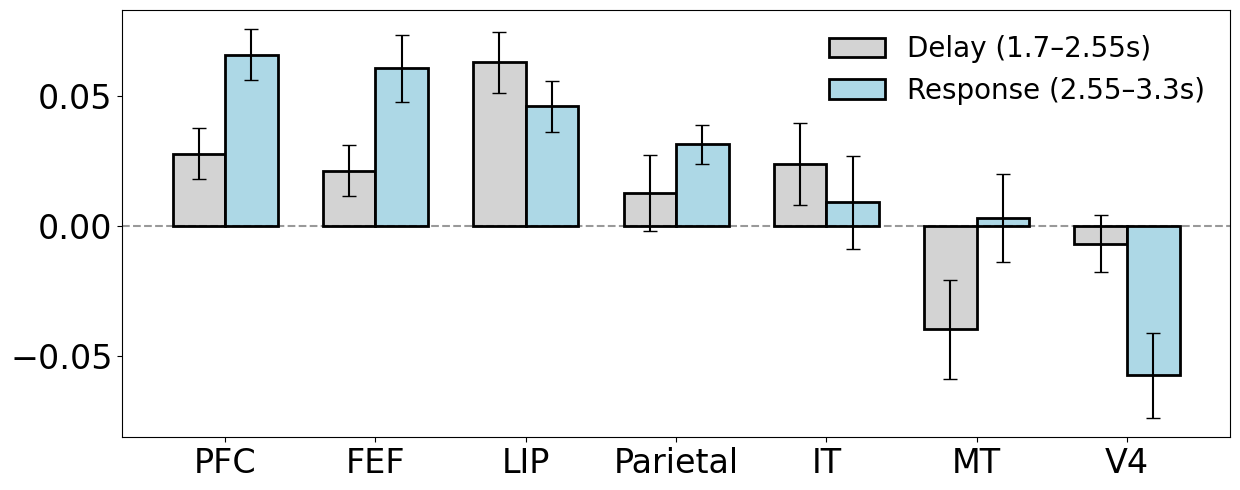

In [7]:


regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']
# area_colors = {'PFC':'b','FEF':'r','LIP':'g','Parietal':'y','IT':'c','MT':'m','V4':'orange'}
area_colors = {'PFC':'k','FEF':'k','LIP':'k','Parietal':'k','IT':'k','MT':'k','V4':'k'}

n_regions = len(regions)
fig, ax = plt.subplots(figsize=(n_regions * 1.5 + 2, 5))

x = np.arange(n_regions)
bar_width = 0.35

delay_means, delay_sems = [], []
response_means, response_sems = [], []

for region in regions:
    df_region = df_merged[df_merged['area'] == region]
    times = np.sort(df_region['time'].unique())
    sessions = df_region['session_id'].dropna().unique()

    r_sessions = np.full((len(sessions), len(times)), np.nan)

    for s_idx, session in enumerate(sessions):
        df_s = df_region[df_region['session_id'] == session]
        for t_idx, t in enumerate(times):
            sub = df_s[np.isclose(df_s['time'], t)]
            if len(sub) > 10:
                neural = np.radians(sub['error_deg'].values)
                behav  = np.radians(sub['err'].values)
                r_sessions[s_idx, t_idx] = circ_corr(neural, behav)

    # Define delay and response masks
    delay_mask = (times >= 1.7) & (times < 2.55)
    response_mask = (times >= 2.55) & (times <= 3.3)

    # Average correlation across time bins per session, then across sessions
    delay_per_session = np.nanmean(r_sessions[:, delay_mask], axis=1)
    response_per_session = np.nanmean(r_sessions[:, response_mask], axis=1)

    n_valid_delay = np.sum(~np.isnan(delay_per_session))
    n_valid_response = np.sum(~np.isnan(response_per_session))

    delay_means.append(np.nanmean(delay_per_session))
    delay_sems.append(np.nanstd(delay_per_session) / np.sqrt(n_valid_delay))

    response_means.append(np.nanmean(response_per_session))
    response_sems.append(np.nanstd(response_per_session) / np.sqrt(n_valid_response))

    print(f"{region} (n={len(sessions)}): Delay={delay_means[-1]:.4f}±{delay_sems[-1]:.4f}, "
          f"Response={response_means[-1]:.4f}±{response_sems[-1]:.4f}")

for i, region in enumerate(regions):
    ax.bar(x[i] - bar_width/2, delay_means[i], bar_width, yerr=delay_sems[i],
           capsize=5, color='lightgray', edgecolor=area_colors[region], linewidth=2)
    ax.bar(x[i] + bar_width/2, response_means[i], bar_width, yerr=response_sems[i],
           capsize=5, color='lightblue', edgecolor=area_colors[region], linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=20)
# ax.set_ylabel('Correlation', fontsize=24)
# ax.set_title('Neural–Behavioral Correlation: Delay vs Response', fontsize=16)
ax.axhline(0, linestyle='--', color='k', alpha=0.4)
ax.tick_params(labelsize=24)

legend_handles = [
    Patch(facecolor='lightgray', edgecolor='k', linewidth=2, label='Delay (1.7–2.55s)'),
    Patch(facecolor='lightblue', edgecolor='k', linewidth=2, label='Response (2.55–3.3s)')
]
leg = ax.legend(handles=legend_handles, fontsize=20)
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()

In [8]:
delay_per_session_dict_corr = {}
response_per_session_dict = {}

for region in regions:
    df_region = df_merged[df_merged['area'] == region]
    times = np.sort(df_region['time'].unique())
    sessions = df_region['session_id'].dropna().unique()

    r_sessions = np.full((len(sessions), len(times)), np.nan)

    for s_idx, session in enumerate(sessions):
        df_s = df_region[df_region['session_id'] == session]
        for t_idx, t in enumerate(times):
            sub = df_s[np.isclose(df_s['time'], t)]
            if len(sub) > 10:
                neural = np.radians(sub['error_deg'].values)
                behav  = np.radians(sub['err'].values)
                r_sessions[s_idx, t_idx] = circ_corr(neural, behav)

    delay_mask = (times >= 1.7) & (times < 2.55)
    response_mask = (times >= 2.55) & (times <= 3.3)

    delay_per_session = np.nanmean(r_sessions[:, delay_mask], axis=1)
    response_per_session = np.nanmean(r_sessions[:, response_mask], axis=1)

    delay_per_session_dict_corr[region] = delay_per_session
    response_per_session_dict[region] = response_per_session

# Optionally print for inspection
for region, vals in delay_per_session_dict_corr.items():
    print(f"{region} delay: {vals}")


PFC delay: [-0.06956828 -0.06899815  0.00749668  0.00210135  0.10366059  0.06042333
  0.00217294  0.07459851 -0.03494808  0.13979545  0.03988919 -0.03499029
  0.05080503  0.09316216 -0.07156236 -0.01852121 -0.03532573  0.13724435
  0.0607172   0.03053857  0.03075595  0.14587617  0.02202498 -0.05000847
 -0.18176098  0.03065728 -0.07793767  0.03711488 -0.05390395  0.20189175
  0.22877376 -0.02829138  0.09020585  0.00634111  0.11361099  0.01401171
  0.04814678  0.01590983  0.00879724 -0.00903539 -0.07806306 -0.09697934
 -0.02122191  0.06471798  0.01790716  0.0619897   0.1500013  -0.03384439
  0.1123954  -0.03214088  0.10156403  0.07140718  0.0968543  -0.03031956
 -0.04489333  0.08382812  0.02308216  0.02822321  0.13908854 -0.01261262]
FEF delay: [-0.00856006 -0.07442463  0.09468126  0.01193145  0.07202398  0.05105327
  0.03143536  0.02972433 -0.02518397  0.23605662  0.07342171  0.10923322
  0.08421155 -0.14124413 -0.02995277 -0.04848056  0.1911361   0.17805022
  0.0217497  -0.00143083  0.

In [9]:
delay_per_session_dict_corr

{'PFC': array([-0.06956828, -0.06899815,  0.00749668,  0.00210135,  0.10366059,
         0.06042333,  0.00217294,  0.07459851, -0.03494808,  0.13979545,
         0.03988919, -0.03499029,  0.05080503,  0.09316216, -0.07156236,
        -0.01852121, -0.03532573,  0.13724435,  0.0607172 ,  0.03053857,
         0.03075595,  0.14587617,  0.02202498, -0.05000847, -0.18176098,
         0.03065728, -0.07793767,  0.03711488, -0.05390395,  0.20189175,
         0.22877376, -0.02829138,  0.09020585,  0.00634111,  0.11361099,
         0.01401171,  0.04814678,  0.01590983,  0.00879724, -0.00903539,
        -0.07806306, -0.09697934, -0.02122191,  0.06471798,  0.01790716,
         0.0619897 ,  0.1500013 , -0.03384439,  0.1123954 , -0.03214088,
         0.10156403,  0.07140718,  0.0968543 , -0.03031956, -0.04489333,
         0.08382812,  0.02308216,  0.02822321,  0.13908854, -0.01261262]),
 'FEF': array([-0.00856006, -0.07442463,  0.09468126,  0.01193145,  0.07202398,
         0.05105327,  0.03143536,  

# FIT Linreg 

In [10]:
from scipy.stats import linregress

regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']

slopes_records = []

for region in regions:
    df_region = df_merged[df_merged['area'] == region]
    times = np.sort(df_region['time'].unique())
    sessions = df_region['session_id'].dropna().unique()

    delay_mask = (times >= 1.7) & (times < 2.55)
    response_mask = (times >= 2.55) & (times <= 3.3)

    for session in sessions:
        df_s = df_region[df_region['session_id'] == session]

        r_values = np.full(len(times), np.nan)
        for t_idx, t in enumerate(times):
            sub = df_s[np.isclose(df_s['time'], t)]
            if len(sub) > 10:
                neural = np.radians(sub['error_deg'].values)
                behav  = np.radians(sub['err'].values)
                r_values[t_idx] = circ_corr(neural, behav)

        # Delay slope
        r_delay = r_values[delay_mask]
        t_delay = times[delay_mask]
        valid_d = ~np.isnan(r_delay)
        if valid_d.sum() > 2:
            slope_d, _, _, pval_d, _ = linregress(t_delay[valid_d], r_delay[valid_d])
        else:
            slope_d, pval_d = np.nan, np.nan

        # Response slope
        r_resp = r_values[response_mask]
        t_resp = times[response_mask]
        valid_r = ~np.isnan(r_resp)
        if valid_r.sum() > 2:
            slope_r, _, _, pval_r, _ = linregress(t_resp[valid_r], r_resp[valid_r])
        else:
            slope_r, pval_r = np.nan, np.nan

        slopes_records.append({
            'area': region,
            'session': int(session),
            'delay_slope': slope_d,
            'delay_pval': pval_d,
            'response_slope': slope_r,
            'response_pval': pval_r,
        })

df_slopes = pd.DataFrame(slopes_records)

# Summary per region
summary = df_slopes.groupby('area').agg(
    n_sessions=('session', 'count'),
    delay_slope_mean=('delay_slope', 'mean'),
    delay_slope_sem=('delay_slope', lambda x: x.std() / np.sqrt(x.notna().sum())),
    response_slope_mean=('response_slope', 'mean'),
    response_slope_sem=('response_slope', lambda x: x.std() / np.sqrt(x.notna().sum())),
).loc[regions]

print(summary.to_string())
print(f"\nTotal records: {len(df_slopes)}")
df_slopes.head(10)

          n_sessions  delay_slope_mean  delay_slope_sem  response_slope_mean  response_slope_sem
area                                                                                            
PFC               60          0.052309         0.024312             0.002234            0.024403
FEF               63          0.094363         0.023779            -0.093418            0.030149
LIP               58          0.123762         0.023614            -0.167638            0.034099
Parietal          23          0.001448         0.041164            -0.060065            0.040856
IT                13          0.083917         0.050601            -0.158390            0.082752
MT                22          0.076546         0.035409             0.007991            0.047123
V4                27          0.015885         0.033042            -0.177973            0.048775

Total records: 266


,area,session,delay_slope,delay_pval,response_slope,response_pval
0,PFC,100725,0.209974,0.028575,0.326329,0.004548
1,PFC,100731,-0.088190,0.330361,0.467479,0.000218
2,PFC,100730,0.136607,0.050073,0.272761,0.059953
3,PFC,100724,0.275968,0.006873,-0.148707,0.092623
4,PFC,100917,0.183784,0.069104,0.056351,0.416715
5,PFC,100915,0.343830,0.000122,-0.006225,0.930568
6,PFC,100726,-0.041967,0.345788,-0.384813,0.019234
7,PFC,101202,0.344367,0.010279,-0.100176,0.358698
8,PFC,101216,0.360961,0.001674,-0.030884,0.837528
9,PFC,101028,0.230699,0.005833,0.076079,0.234774


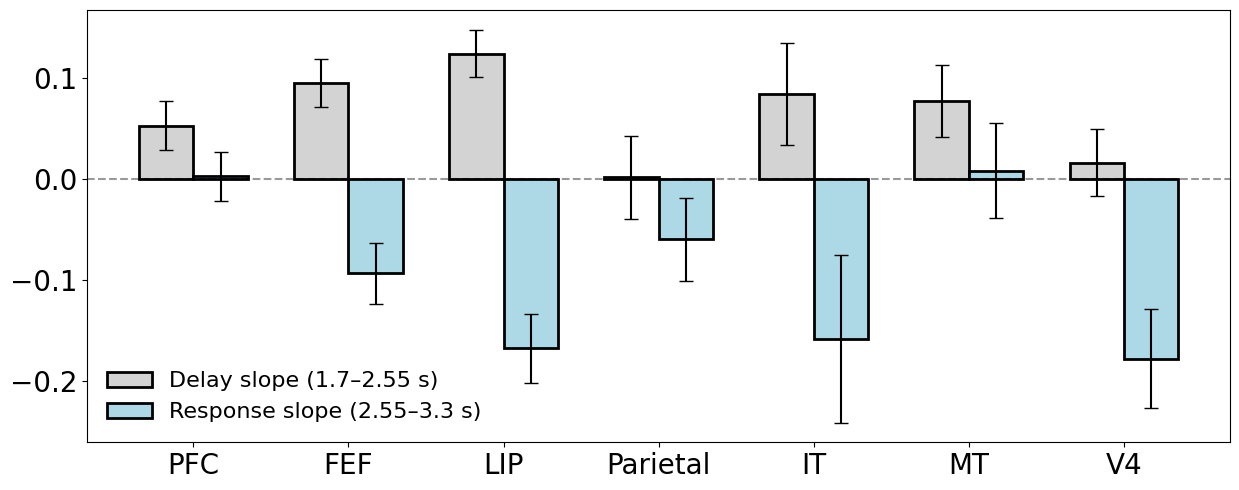

In [11]:
regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']

n_regions = len(regions)
fig, ax = plt.subplots(figsize=(n_regions * 1.5 + 2, 5))

x = np.arange(n_regions)
bar_width = 0.35

delay_means = summary['delay_slope_mean'].values
delay_sems = summary['delay_slope_sem'].values
response_means = summary['response_slope_mean'].values
response_sems = summary['response_slope_sem'].values

for i, region in enumerate(regions):
    ax.bar(x[i] - bar_width/2, delay_means[i], bar_width, yerr=delay_sems[i],
           capsize=5, color='lightgray', edgecolor='k', linewidth=2)
    ax.bar(x[i] + bar_width/2, response_means[i], bar_width, yerr=response_sems[i],
           capsize=5, color='lightblue', edgecolor='k', linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=20)
# ax.set_ylabel('Slope (corr / s)', fontsize=20)
ax.axhline(0, linestyle='--', color='k', alpha=0.4)
ax.tick_params(labelsize=20)

legend_handles = [
    Patch(facecolor='lightgray', edgecolor='k', linewidth=2, label='Delay slope (1.7–2.55 s)'),
    Patch(facecolor='lightblue', edgecolor='k', linewidth=2, label='Response slope (2.55–3.3 s)')
]
leg = ax.legend(handles=legend_handles, fontsize=16)
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()

# DECODING

In [12]:
with open('/home/aarghavan/aslan/delsac-neural-decoding/results/per_session_circcorr.pkl', 'rb') as f:
    data = pickle.load(f)

In [13]:
print(data.keys()   )
print(data['PFC'].keys())
print(data['PFC'][0].keys())
print(len(data['PFC'][0]['targetAngle']))


dict_keys(['PFC', 'FEF', 'IT', 'MT', 'LIP', 'Parietal', 'V4'])
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 62, 63, 64, 65])
dict_keys(['targetAngle', 'respAngle', 'prevTargetAngle', 'prevRespAngle'])
59


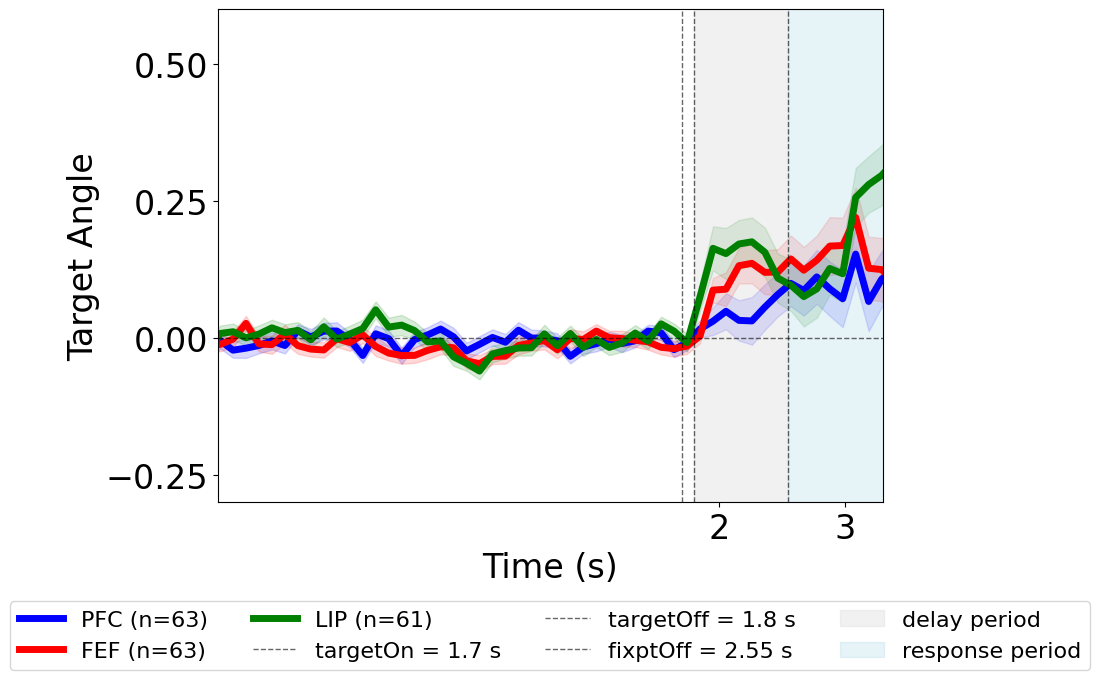

In [14]:
# regions = ['Parietal', 'IT', 'MT', 'V4']
regions = ['PFC', 'FEF', 'LIP']
area_colors = {'PFC':'b','FEF':'r','LIP':'g','Parietal':'y','IT':'c','MT':'m','V4':'orange'}

plt.figure(figsize=(10, 7))

for region in regions:
    session_keys = list(data[region].keys())
    n_sessions = len(session_keys)
    all_sessions = np.array([data[region][s]['targetAngle'] for s in session_keys])
    
    mean_ts = np.nanmean(all_sessions, axis=0)
    sem_ts = np.nanstd(all_sessions, axis=0) / np.sqrt(n_sessions)
    
    n_bins = len(mean_ts)
    time_sec = np.linspace(-2.5, 3.5, n_bins)
    
    plt.plot(time_sec, mean_ts, linewidth=5, label=f'{region} (n={n_sessions})',
             color=area_colors.get(region, 'black'))
    plt.fill_between(time_sec, mean_ts - sem_ts, mean_ts + sem_ts, alpha=0.15,
                     color=area_colors.get(region, 'black'))

plt.axhline(0, linestyle='--', color='k', alpha=0.6, linewidth=1)

# plt.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.15, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.2, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.35, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.4, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.55, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.6, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.75, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(0.8, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(0.95, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

# plt.axvline(1, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOn
# plt.axvline(1.15, color='k', linestyle='--', linewidth=1, alpha=0.6) #stimOff

plt.axvline(1.7, linestyle='--', color='k', alpha=0.6, label='targetOn = 1.7 s', linewidth=1) #targetOn

plt.axvline(1.8, linestyle='--', color='k', alpha=0.6, label='targetOff = 1.8 s', linewidth=1)#targetOff

plt.axvline(2.55, linestyle='--', color='k', alpha=0.6, label='fixptOff = 2.55 s', linewidth=1)

plt.axvspan(1.8, 2.55, color='lightgray', alpha=0.3, label='delay period')
plt.axvspan(2.55, 3.5, color='lightblue', alpha=0.3, label='response period')

plt.xlabel('Time (s)', fontsize=24)
plt.ylabel('Target Angle', fontsize=24)
plt.xticks([ 2, 3], fontsize=24)
plt.yticks([-0.25, 0, 0.25, 0.5], fontsize=24)
plt.xlim(-2, 3.3)
plt.ylim(-0.3, 0.6)
plt.legend(fontsize=16, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, borderaxespad=0)
plt.tight_layout()
plt.show()

PFC (n=63): Delay=0.0581±0.0243, Response=0.1122±0.0347
FEF (n=63): Delay=0.1191±0.0270, Response=0.1460±0.0379
LIP (n=61): Delay=0.1378±0.0386, Response=0.2155±0.0365
Parietal (n=26): Delay=0.0835±0.0273, Response=0.1482±0.0370
IT (n=13): Delay=0.0364±0.0261, Response=0.0764±0.0285
MT (n=22): Delay=0.1039±0.0426, Response=0.1838±0.0306
V4 (n=29): Delay=0.0358±0.0163, Response=0.0989±0.0200


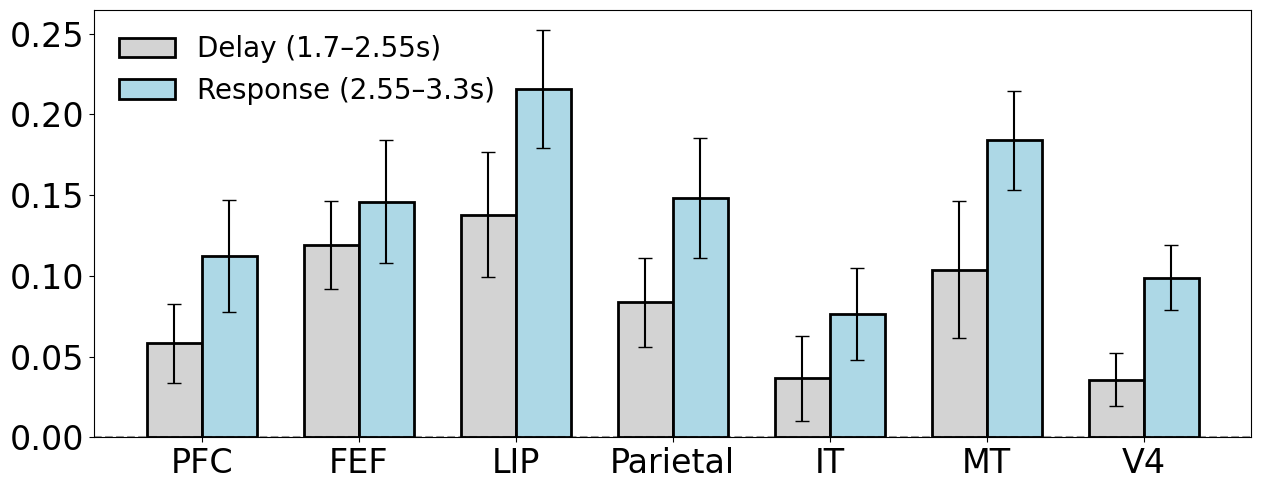

In [15]:
regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']
# area_colors = {'PFC':'b','FEF':'r','LIP':'g','Parietal':'y','IT':'c','MT':'m','V4':'orange'}
area_colors = {'PFC':'k','FEF':'k','LIP':'k','Parietal':'k','IT':'k','MT':'k','V4':'k'}

n_regions = len(regions)
fig, ax = plt.subplots(figsize=(n_regions * 1.5 + 2, 5))

x = np.arange(n_regions)
bar_width = 0.35

delay_means, delay_sems = [], []
response_means, response_sems = [], []

for region in regions:
    session_keys = list(data[region].keys())
    n_sessions = len(session_keys)
    all_sessions = np.array([data[region][s]['targetAngle'] for s in session_keys])

    n_bins = all_sessions.shape[1]
    time_sec = np.linspace(-2.5, 3.3, n_bins)

    delay_mask = (time_sec >= 1.7) & (time_sec < 2.55)
    response_mask = (time_sec >= 2.55) & (time_sec <= 3.3)

    delay_per_session = np.nanmean(all_sessions[:, delay_mask], axis=1)
    response_per_session = np.nanmean(all_sessions[:, response_mask], axis=1)

    delay_means.append(np.nanmean(delay_per_session))
    delay_sems.append(np.nanstd(delay_per_session) / np.sqrt(n_sessions))

    response_means.append(np.nanmean(response_per_session))
    response_sems.append(np.nanstd(response_per_session) / np.sqrt(n_sessions))

    print(f"{region} (n={n_sessions}): Delay={delay_means[-1]:.4f}±{delay_sems[-1]:.4f}, "
          f"Response={response_means[-1]:.4f}±{response_sems[-1]:.4f}")

for i, region in enumerate(regions):
    ax.bar(x[i] - bar_width/2, delay_means[i], bar_width, yerr=delay_sems[i],
           capsize=5, color='lightgray', edgecolor=area_colors[region], linewidth=2)
    ax.bar(x[i] + bar_width/2, response_means[i], bar_width, yerr=response_sems[i],
           capsize=5, color='lightblue', edgecolor=area_colors[region], linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=20)
ax.axhline(0, linestyle='--', color='k', alpha=0.4)
ax.tick_params(labelsize=24)

# Manual legend with neutral edge colors
legend_handles = [
    Patch(facecolor='lightgray', edgecolor='k', linewidth=2, label='Delay (1.7–2.55s)'),
    Patch(facecolor='lightblue', edgecolor='k', linewidth=2, label='Response (2.55–3.3s)')
]
leg = ax.legend(handles=legend_handles, fontsize=20)
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()

In [16]:
delay_per_session_dict_decoding = {}

for region in regions:
    session_keys = list(data[region].keys())
    n_sessions = len(session_keys)
    all_sessions = np.array([data[region][s]['targetAngle'] for s in session_keys])

    n_bins = all_sessions.shape[1]
    time_sec = np.linspace(-2.5, 3.3, n_bins)

    delay_mask = (time_sec >= 1.7) & (time_sec < 2.55)
    delay_per_session = np.nanmean(all_sessions[:, delay_mask], axis=1)

    delay_per_session_dict_decoding[region] = delay_per_session

# Optionally, print or inspect
for region, vals in delay_per_session_dict_decoding.items():
    print(f"{region}: {vals}")

PFC: [ 0.00075825 -0.0302571  -0.22732043  0.01278805  0.1000332  -0.46639839
  0.37088211  0.0300474  -0.08448697  0.28147929 -0.18127866  0.03939706
  0.1942289   0.49142705  0.03178532 -0.00914471  0.30925702 -0.37430284
  0.07212856 -0.0108273   0.17256212  0.07302492  0.02196554  0.45307631
 -0.04352519  0.08291612 -0.01368196  0.20576806  0.16864146  0.17098359
 -0.06340833  0.14566852  0.1066917   0.13529358  0.13941826  0.3127549
  0.20096516 -0.02557818  0.00974283  0.41731676 -0.15276791 -0.0963899
 -0.25464953  0.163863    0.36114955 -0.0222496   0.01743317  0.17571262
  0.33218018 -0.36788349 -0.11563378 -0.24833327  0.0557207  -0.01462837
 -0.01091464  0.04337107  0.01670483  0.07938049  0.09803418 -0.15608259
  0.26863917  0.09632647  0.17248811]
FEF: [ 0.32339043  0.33576602 -0.12068804  0.01566275  0.17346239  0.35920563
  0.40881519  0.06416552 -0.15613149  0.23902666  0.32440949 -0.10608368
  0.2783016   0.0537562  -0.01549053  0.24841292  0.1306971   0.35767793
 -0.1

In [17]:
delay_per_session_dict_decoding

{'PFC': array([ 0.00075825, -0.0302571 , -0.22732043,  0.01278805,  0.1000332 ,
        -0.46639839,  0.37088211,  0.0300474 , -0.08448697,  0.28147929,
        -0.18127866,  0.03939706,  0.1942289 ,  0.49142705,  0.03178532,
        -0.00914471,  0.30925702, -0.37430284,  0.07212856, -0.0108273 ,
         0.17256212,  0.07302492,  0.02196554,  0.45307631, -0.04352519,
         0.08291612, -0.01368196,  0.20576806,  0.16864146,  0.17098359,
        -0.06340833,  0.14566852,  0.1066917 ,  0.13529358,  0.13941826,
         0.3127549 ,  0.20096516, -0.02557818,  0.00974283,  0.41731676,
        -0.15276791, -0.0963899 , -0.25464953,  0.163863  ,  0.36114955,
        -0.0222496 ,  0.01743317,  0.17571262,  0.33218018, -0.36788349,
        -0.11563378, -0.24833327,  0.0557207 , -0.01462837, -0.01091464,
         0.04337107,  0.01670483,  0.07938049,  0.09803418, -0.15608259,
         0.26863917,  0.09632647,  0.17248811]),
 'FEF': array([ 0.32339043,  0.33576602, -0.12068804,  0.01566275,  

In [18]:
from scipy.stats import linregress

regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']

decoding_slopes_records = []

for region in regions:
    session_keys = list(data[region].keys())

    for s in session_keys:
        ts = np.array(data[region][s]['targetAngle'])
        n_bins = len(ts)
        time_sec = np.linspace(-2.5, 3.3, n_bins)

        delay_mask = (time_sec >= 1.7) & (time_sec < 2.55)
        response_mask = (time_sec >= 2.55) & (time_sec <= 3.3)

        # Delay slope
        t_delay = time_sec[delay_mask]
        r_delay = ts[delay_mask]
        valid_d = ~np.isnan(r_delay)
        if valid_d.sum() > 2:
            slope_d, _, _, pval_d, _ = linregress(t_delay[valid_d], r_delay[valid_d])
        else:
            slope_d, pval_d = np.nan, np.nan

        # Response slope
        t_resp = time_sec[response_mask]
        r_resp = ts[response_mask]
        valid_r = ~np.isnan(r_resp)
        if valid_r.sum() > 2:
            slope_r, _, _, pval_r, _ = linregress(t_resp[valid_r], r_resp[valid_r])
        else:
            slope_r, pval_r = np.nan, np.nan

        decoding_slopes_records.append({
            'area': region,
            'session': s,
            'delay_slope': slope_d,
            'delay_pval': pval_d,
            'response_slope': slope_r,
            'response_pval': pval_r,
        })

df_decoding_slopes = pd.DataFrame(decoding_slopes_records)

decoding_summary = df_decoding_slopes.groupby('area').agg(
    n_sessions=('session', 'count'),
    delay_slope_mean=('delay_slope', 'mean'),
    delay_slope_sem=('delay_slope', lambda x: x.std() / np.sqrt(x.notna().sum())),
    response_slope_mean=('response_slope', 'mean'),
    response_slope_sem=('response_slope', lambda x: x.std() / np.sqrt(x.notna().sum())),
).loc[regions]

print(decoding_summary.to_string())
print(f"\nTotal records: {len(df_decoding_slopes)}")

          n_sessions  delay_slope_mean  delay_slope_sem  response_slope_mean  response_slope_sem
area                                                                                            
PFC               63          0.096871         0.061657             0.073809            0.076488
FEF               63          0.057094         0.058468            -0.088134            0.106657
LIP               61         -0.132214         0.065283             0.304456            0.105361
Parietal          26          0.006327         0.057415             0.197284            0.094412
IT                13          0.012857         0.090681             0.090852            0.071573
MT                22         -0.030550         0.065750             0.226823            0.099268
V4                29          0.064033         0.050370             0.035230            0.075843

Total records: 277


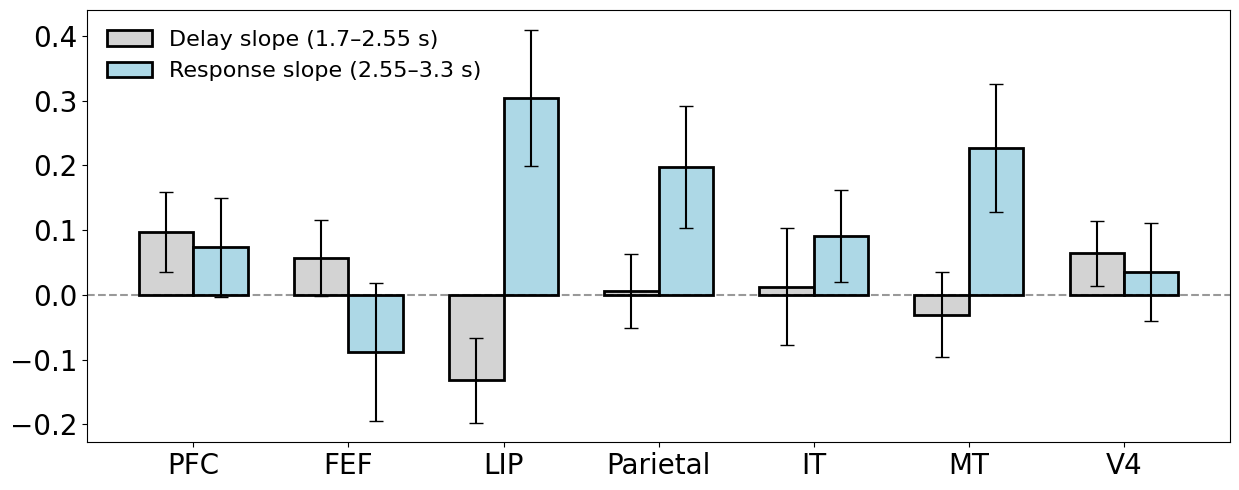

In [19]:
regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']

n_regions = len(regions)
fig, ax = plt.subplots(figsize=(n_regions * 1.5 + 2, 5))

x = np.arange(n_regions)
bar_width = 0.35

delay_means = decoding_summary['delay_slope_mean'].values
delay_sems = decoding_summary['delay_slope_sem'].values
response_means = decoding_summary['response_slope_mean'].values
response_sems = decoding_summary['response_slope_sem'].values

for i, region in enumerate(regions):
    ax.bar(x[i] - bar_width/2, delay_means[i], bar_width, yerr=delay_sems[i],
           capsize=5, color='lightgray', edgecolor='k', linewidth=2)
    ax.bar(x[i] + bar_width/2, response_means[i], bar_width, yerr=response_sems[i],
           capsize=5, color='lightblue', edgecolor='k', linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(regions, fontsize=20)
# ax.set_ylabel('Slope (decoding / s)', fontsize=20)
ax.axhline(0, linestyle='--', color='k', alpha=0.4)
ax.tick_params(labelsize=20)

legend_handles = [
    Patch(facecolor='lightgray', edgecolor='k', linewidth=2, label='Delay slope (1.7–2.55 s)'),
    Patch(facecolor='lightblue', edgecolor='k', linewidth=2, label='Response slope (2.55–3.3 s)')
]
leg = ax.legend(handles=legend_handles, fontsize=16)
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()

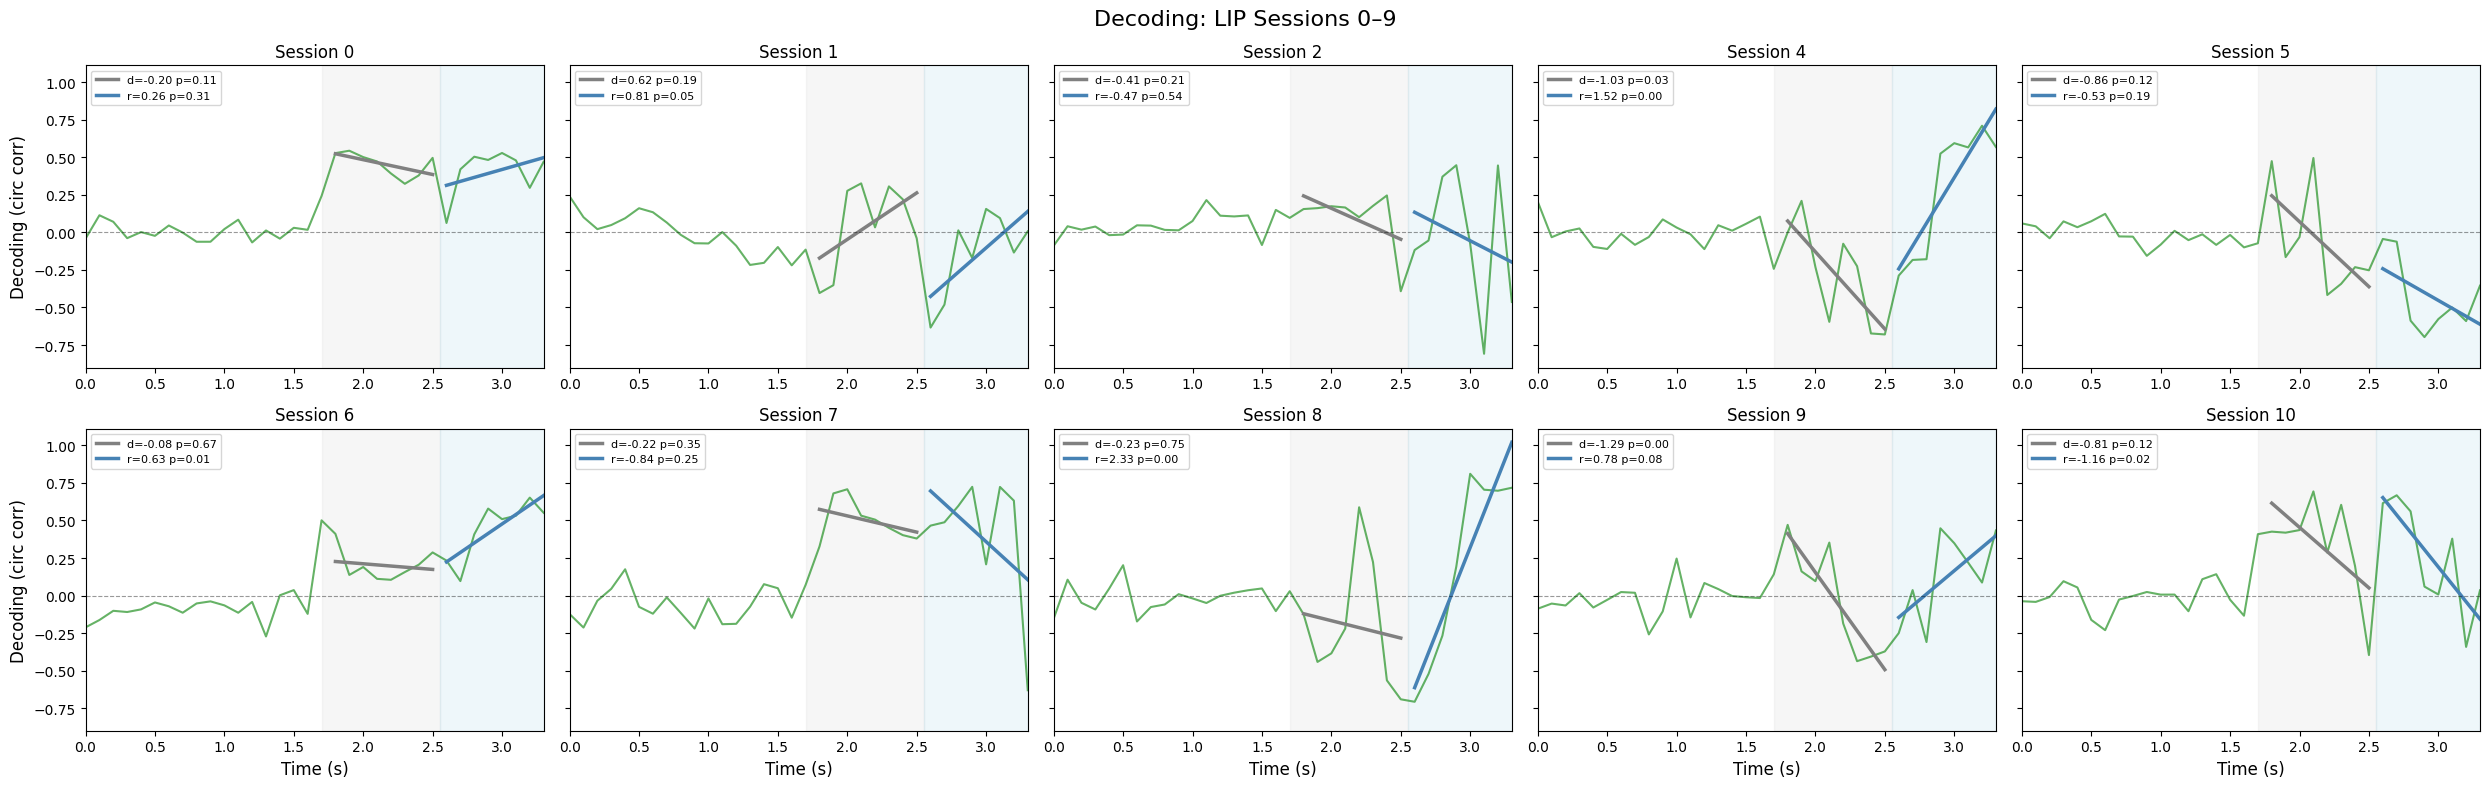

In [20]:
from scipy.stats import linregress

region = 'LIP'
session_keys = list(data[region].keys())[:10]

fig, axes = plt.subplots(2, 5, figsize=(25, 8), sharey=True)
axes = axes.flatten()

for i, s_key in enumerate(session_keys):
    ax = axes[i]
    
    ts = np.array(data[region][s_key]['targetAngle'])
    n_bins = len(ts)
    time_sec = np.linspace(-2.5, 3.3, n_bins)

    delay_mask = (time_sec >= 1.7) & (time_sec < 2.55)
    response_mask = (time_sec >= 2.55) & (time_sec <= 3.3)

    # Fit linreg
    valid_d = ~np.isnan(ts[delay_mask])
    slope_d, intercept_d, _, pval_d, _ = linregress(time_sec[delay_mask][valid_d], ts[delay_mask][valid_d])

    valid_r = ~np.isnan(ts[response_mask])
    slope_r, intercept_r, _, pval_r, _ = linregress(time_sec[response_mask][valid_r], ts[response_mask][valid_r])

    ax.plot(time_sec, ts, linewidth=1.5, color='g', alpha=0.6)
    ax.plot(time_sec[delay_mask], slope_d * time_sec[delay_mask] + intercept_d,
            linewidth=2.5, color='gray', label=f'd={slope_d:.2f} p={pval_d:.2f}')
    ax.plot(time_sec[response_mask], slope_r * time_sec[response_mask] + intercept_r,
            linewidth=2.5, color='steelblue', label=f'r={slope_r:.2f} p={pval_r:.2f}')

    ax.axhline(0, linestyle='--', color='k', alpha=0.4, linewidth=0.8)
    ax.axvspan(1.7, 2.55, color='lightgray', alpha=0.2)
    ax.axvspan(2.55, 3.3, color='lightblue', alpha=0.2)
    ax.set_xlim(0, 3.3)
    ax.set_title(f'Session {s_key}', fontsize=12)
    ax.legend(fontsize=8, loc='upper left')

    if i >= 5:
        ax.set_xlabel('Time (s)', fontsize=12)
    if i % 5 == 0:
        ax.set_ylabel('Decoding (circ corr)', fontsize=12)

fig.suptitle(f'Decoding: LIP Sessions 0–9', fontsize=16)
plt.tight_layout()
plt.show()

In [21]:
# Demean per region for both dicts
demeaned_corr = {}
demeaned_decoding = {}

for region in regions:
    vals_corr = delay_per_session_dict_corr[region]
    vals_decoding = delay_per_session_dict_decoding[region]
    demeaned_corr[region] = vals_corr - np.nanmean(vals_corr)
    demeaned_decoding[region] = vals_decoding - np.nanmean(vals_decoding)

# Optionally print to check
for region in regions:
    print(f"{region} demeaned corr: {demeaned_corr[region]}")
    print(f"{region} demeaned decoding: {demeaned_decoding[region]}")

PFC demeaned corr: [-0.09728254 -0.09671241 -0.02021758 -0.02561291  0.07594633  0.03270907
 -0.02554132  0.04688425 -0.06266234  0.11208119  0.01217493 -0.06270455
  0.02309077  0.0654479  -0.09927662 -0.04623548 -0.06303999  0.10953009
  0.03300294  0.00282431  0.00304168  0.11816191 -0.00568928 -0.07772274
 -0.20947524  0.00294302 -0.10565193  0.00940062 -0.08161821  0.17417749
  0.2010595  -0.05600564  0.06249159 -0.02137315  0.08589673 -0.01370256
  0.02043252 -0.01180443 -0.01891702 -0.03674965 -0.10577732 -0.1246936
 -0.04893617  0.03700372 -0.0098071   0.03427544  0.12228704 -0.06155865
  0.08468114 -0.05985514  0.07384977  0.04369292  0.06914003 -0.05803382
 -0.07260759  0.05611386 -0.00463211  0.00050895  0.11137428 -0.04032688]
PFC demeaned decoding: [-0.0573729  -0.08838825 -0.28545158 -0.0453431   0.04190205 -0.52452954
  0.31275096 -0.02808375 -0.14261812  0.22334814 -0.23940981 -0.01873409
  0.13609775  0.4332959  -0.02634583 -0.06727586  0.25112587 -0.43243399
  0.01399

In [22]:
delay_per_session_dict_corr

{'PFC': array([-0.06956828, -0.06899815,  0.00749668,  0.00210135,  0.10366059,
         0.06042333,  0.00217294,  0.07459851, -0.03494808,  0.13979545,
         0.03988919, -0.03499029,  0.05080503,  0.09316216, -0.07156236,
        -0.01852121, -0.03532573,  0.13724435,  0.0607172 ,  0.03053857,
         0.03075595,  0.14587617,  0.02202498, -0.05000847, -0.18176098,
         0.03065728, -0.07793767,  0.03711488, -0.05390395,  0.20189175,
         0.22877376, -0.02829138,  0.09020585,  0.00634111,  0.11361099,
         0.01401171,  0.04814678,  0.01590983,  0.00879724, -0.00903539,
        -0.07806306, -0.09697934, -0.02122191,  0.06471798,  0.01790716,
         0.0619897 ,  0.1500013 , -0.03384439,  0.1123954 , -0.03214088,
         0.10156403,  0.07140718,  0.0968543 , -0.03031956, -0.04489333,
         0.08382812,  0.02308216,  0.02822321,  0.13908854, -0.01261262]),
 'FEF': array([-0.00856006, -0.07442463,  0.09468126,  0.01193145,  0.07202398,
         0.05105327,  0.03143536,  

In [23]:
delay_per_session_dict_decoding

{'PFC': array([ 0.00075825, -0.0302571 , -0.22732043,  0.01278805,  0.1000332 ,
        -0.46639839,  0.37088211,  0.0300474 , -0.08448697,  0.28147929,
        -0.18127866,  0.03939706,  0.1942289 ,  0.49142705,  0.03178532,
        -0.00914471,  0.30925702, -0.37430284,  0.07212856, -0.0108273 ,
         0.17256212,  0.07302492,  0.02196554,  0.45307631, -0.04352519,
         0.08291612, -0.01368196,  0.20576806,  0.16864146,  0.17098359,
        -0.06340833,  0.14566852,  0.1066917 ,  0.13529358,  0.13941826,
         0.3127549 ,  0.20096516, -0.02557818,  0.00974283,  0.41731676,
        -0.15276791, -0.0963899 , -0.25464953,  0.163863  ,  0.36114955,
        -0.0222496 ,  0.01743317,  0.17571262,  0.33218018, -0.36788349,
        -0.11563378, -0.24833327,  0.0557207 , -0.01462837, -0.01091464,
         0.04337107,  0.01670483,  0.07938049,  0.09803418, -0.15608259,
         0.26863917,  0.09632647,  0.17248811]),
 'FEF': array([ 0.32339043,  0.33576602, -0.12068804,  0.01566275,  

In [24]:
# # regions = ['PFC', 'FEF', 'LIP', 'Parietal', 'IT', 'MT', 'V4']
# regions = ['PFC']
# area_colors = {'PFC':'b','FEF':'r','LIP':'g','Parietal':'y','IT':'c','MT':'m','V4':'orange'}

# plt.figure(figsize=(8, 12))

# for region in regions:
#     x = demeaned_corr[region]
#     y = demeaned_decoding[region]
#     plt.scatter(x, y, label=region, color=area_colors[region], s=80, alpha=0.8)

# plt.xlabel('Neural-Behavioral Corr (delay, per session)', fontsize=20)
# plt.ylabel('Decoding (delay, per session)', fontsize=20)
# plt.title('Session-wise Correlation: Neural-Behavioral vs Decoding', fontsize=20)
# plt.axhline(0, color='k', linestyle='--', alpha=0.3)
# plt.axvline(0, color='k', linestyle='--', alpha=0.3)
# plt.legend(fontsize=20, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1, borderaxespad=0)
# plt.xticks([-0.25, 0, 0.25], fontsize=16)
# plt.yticks([-0.5, 0, 0.5], fontsize=16)
# plt.xlim(-0.3, 0.3)
# plt.ylim(-0.9, 0.9)
# plt.tight_layout()
# plt.show()



In [25]:
print(demeaned_corr['PFC'].shape)
print(demeaned_decoding['PFC'].shape)

(60,)
(63,)


In [27]:
# from scipy.stats import pearsonr
# import numpy as np

# all_corr = np.concatenate([demeaned_corr[r] for r in regions])
# all_decoding = np.concatenate([demeaned_decoding[r] for r in regions])

# mask = ~np.isnan(all_corr) & ~np.isnan(all_decoding)
# r, p = pearsonr(all_corr[mask], all_decoding[mask])

# print(f"Pearson correlation: r = {r:.3f}, p = {p:.3g}")